## Week 5 – Exploratory Analysis & Basic Feature Engineering

This section focuses on understanding the housing dataset through basic feature creation and exploratory analysis of pricing and market behavior.

In [1]:
# Step 1:  Load cleaned data set

import pandas as pd

sold = pd.read_csv("../output/sold_cleaned.csv")

print(sold.shape)
sold.head()

/var/folders/j3/fcm5lwl97232mcc0j6k8vwnr0000gn/T/ipykernel_15956/2965149881.py:5: DtypeWarning: Columns (0,1,4,9,64,78,79,80,82,83) have mixed types. Specify dtype option on import or set low_memory=False.
  sold = pd.read_csv("../output/sold_cleaned.csv")


(397123, 90)


,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,BuyerAgencyCompensationType,BuyerAgencyCompensation,latfilled,lonfilled,listing_after_close_flag,purchase_after_close_flag,negative_timeline_flag,missing_coord_flag,zero_coord_flag,invalid_longitude_flag
0,Mlslistings,Mlslistings,"Carpet,Tile,Wood",True,NaN,NaN,False,499000.0,551985747,jwachter@cbnorcal.com,...,NaN,NaN,NaN,NaN,False,False,False,True,False,False
1,SanDiego,SanDiego,NaN,False,NaN,NaN,False,759900.0,522107581,mdarwich12@gmail.com,...,NaN,NaN,NaN,NaN,False,False,False,True,False,False
2,SanDiego,SanDiego,NaN,False,NaN,NaN,False,739900.0,510919001,mdarwich12@gmail.com,...,NaN,NaN,NaN,NaN,False,False,False,True,False,False
3,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,NaN,1079166779,davidmartz@compass.com,...,NaN,NaN,NaN,NaN,False,True,False,True,False,False
4,Southland,Southland,NaN,False,NaN,NaN,False,1890500.0,1075037759,karen.klein@theagencyre.com,...,NaN,NaN,NaN,NaN,False,False,False,False,False,False


### Step 2: Feature Engineering


#### 1. Price Per Square Foot

In [2]:

sold['price_per_sqft'] = sold['ClosePrice'] / sold['LivingArea']

#### 2. Sale vs List ration

In [3]:
sold['sale_to_list_ratio'] = sold['ClosePrice'] / sold['ListPrice']

In [4]:
# Basic features
sold[['price_per_sqft', 'sale_to_list_ratio']].describe()

,price_per_sqft,sale_to_list_ratio
count,3.971230e+05,3.971230e+05
mean,6.455035e+02,1.078369e+00
std,5.085216e+03,8.433558e+00
min,4.981497e-04,9.591326e-07
25%,3.683962e+02,9.764574e-01
50%,5.373303e+02,1.000000e+00
75%,7.322654e+02,1.019672e+00
max,1.164067e+06,1.153846e+03


#### 3. Days to close

In [5]:
sold['days_to_close'] = (
    pd.to_datetime(sold['CloseDate']) - 
    pd.to_datetime(sold['ListingContractDate'])
).dt.days

#### 4. Extract Year + month

In [6]:
sold['CloseDate'] = pd.to_datetime(sold['CloseDate'], errors='coerce')

sold['year'] = pd.to_datetime(sold['CloseDate']).dt.year
sold['month'] = pd.to_datetime(sold['CloseDate']).dt.month

sold[['year', 'month']].head()

,year,month
0,2024,1
1,2024,1
2,2024,1
3,2024,1
4,2024,1


### Step 3: Answer Question

##### Q1. Median Home Price (typical)

In [7]:
median_price = sold['ClosePrice'].median()
print("Median Home Price:", median_price)

Median Home Price: 820000.0


#### Q2. Most Expensive Counties

In [8]:
sold.groupby('CountyOrParish')['ClosePrice'].median().sort_values(ascending=False).head(10)

CountyOrParish
Del Norte        2485000.0
San Mateo        1700000.0
Santa Clara      1600000.0
Santa Cruz       1200000.0
San Francisco    1180000.0
Orange           1175000.0
Marin            1170000.0
Alameda          1135000.0
Alpine           1100000.0
Mono              915000.0
Name: ClosePrice, dtype: float64

#### Q3. Do homes sell above list price?

In [9]:
sold['sale_to_list_ratio'].mean()

np.float64(1.0783694315495498)

Most homes sell close to their listing price, with some properties selling above list price, indicating competitive demand in certain segments of the market.

#### Q4. Fastest Selling Areas

In [ ]:
sold['DaysOnMarket'].median()

The median days on market provides insight into how quickly homes are selling, reflecting overall market demand and liquidity.

In [10]:
sold.groupby('CountyOrParish')['DaysOnMarket'].median().sort_values(ascending=False).head(10)

CountyOrParish
Del Norte          320.0
Foreign Country    310.0
Alpine             231.0
Lassen             150.0
Other              138.0
Trinity            136.0
Humboldt            81.0
Amador              78.0
Mono                73.0
Plumas              63.5
Name: DaysOnMarket, dtype: float64

##### Visualization

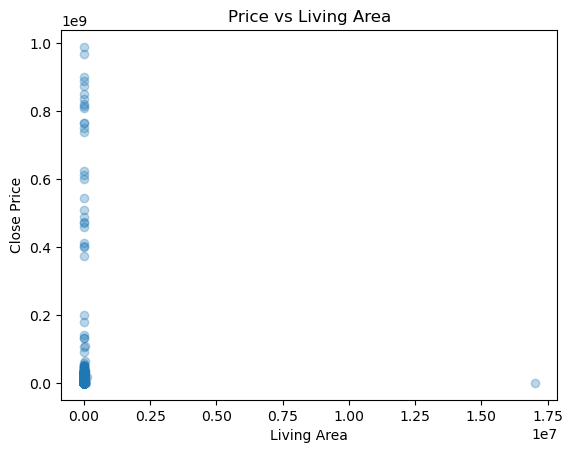

In [11]:
import matplotlib.pyplot as plt

plt.scatter(sold['LivingArea'], sold['ClosePrice'], alpha=0.3)
plt.xlabel("Living Area")
plt.ylabel("Close Price")
plt.title("Price vs Living Area")
plt.show()

In [ ]:
sold['ClosePrice'].hist(bins=50)
plt.title("Distribution of Home Prices")
plt.show()

### Week 5 – Key Insights


- Created basic features such as price per square foot and sale-to-list ratio to better understand property value  
- Observed that home prices vary across regions, indicating location plays a significant role in pricing  
- Found that many homes sell close to or slightly above listing price, suggesting competitive market conditions  
- Identified typical time on market, providing insight into how quickly homes are sold  
- Established a foundational understanding of the dataset to support deeper analysis in the next stage  